In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("space_weather_unified.csv")

In [3]:
df.tail()

,event_id,event_type,begin_time,peak_time,end_time,class_type,source_location,active_region,instruments,note,kp_index,observed_time,source,date,year,month,day,hour
1738,2025-06-27T08:00:00-HSS-001,High Speed Stream,2025-06-27 08:00:00+00:00,NaN,NaN,NaN,NaN,NaN,"STEREO A: PLASTIC, STEREO A: IMPACT",NaN,NaN,NaN,NaN,2025-06-27,2025,6,27,8
1739,2025-06-28T19:40:00-FLR-001,Solar Flare,2025-06-28 19:40:00+00:00,2025-06-28 19:54:00+00:00,2025-06-28 20:01:00+00:00,C4.0,N07W22,14126.0,GOES-P: EXIS 1.0-8.0,NaN,NaN,NaN,NaN,2025-06-28,2025,6,28,19
1740,2025-07-05T05:38:00-HSS-001,High Speed Stream,2025-07-05 05:38:00+00:00,NaN,NaN,NaN,NaN,NaN,"DSCOVR: PLASMAG, ACE: SWEPAM, ACE: MAG",NaN,NaN,NaN,NaN,2025-07-05,2025,7,5,5
1741,2025-07-08T03:42:00-FLR-001,Solar Flare,2025-07-08 03:42:00+00:00,2025-07-08 04:17:00+00:00,2025-07-08 04:37:00+00:00,M2.4,N22E90,14136.0,GOES-P: EXIS 1.0-8.0,"At the time of this event, this flare originat...",NaN,NaN,NaN,2025-07-08,2025,7,8,3
1742,2025-07-09T04:10:00-FLR-001,Solar Flare,2025-07-09 04:10:00+00:00,2025-07-09 04:25:00+00:00,2025-07-09 04:38:00+00:00,M1.3,N22E75,14136.0,GOES-P: EXIS 1.0-8.0,NaN,NaN,NaN,NaN,2025-07-09,2025,7,9,4


In [4]:
df_labeling = pd.read_csv("geomagnetic_storms.csv")

In [5]:
df_labeling.tail()

,event_id,event_type,begin_time,peak_time,end_time,class_type,source_location,active_region,kp_index,observed_time,source,instruments,note
36,2025-04-15T18:00:00-GST-001,Geomagnetic Storm,2025-04-15T18:00Z,NaN,NaN,G0,NaN,NaN,6.00,2025-04-15T21:00Z,NOAA,NaN,NaN
37,2025-05-17T00:00:00-GST-001,Geomagnetic Storm,2025-05-17T00:00Z,NaN,NaN,G0,NaN,NaN,6.33,2025-05-17T03:00Z,NOAA,NaN,NaN
38,2025-05-29T00:00:00-GST-001,Geomagnetic Storm,2025-05-29T00:00Z,NaN,NaN,G0,NaN,NaN,6.67,2025-05-29T03:00Z,NOAA,NaN,NaN
39,2025-06-01T06:00:00-GST-001,Geomagnetic Storm,2025-06-01T06:00Z,NaN,NaN,G0,NaN,NaN,8.00,2025-06-01T09:00Z,NOAA,NaN,NaN
40,2025-06-13T00:00:00-GST-001,Geomagnetic Storm,2025-06-13T00:00Z,NaN,NaN,G0,NaN,NaN,6.33,2025-06-13T03:00Z,NOAA,NaN,NaN


In [6]:
print(df.isnull().sum())

event_id              0
event_type            0
begin_time            0
peak_time           144
end_time            144
class_type          103
source_location     144
active_region       191
instruments          41
note               1345
kp_index           1702
observed_time      1702
source             1702
date                  0
year                  0
month                 0
day                   0
hour                  0
dtype: int64


In [2]:
import pandas as pd

# Verileri yükle (Zaten yüklediğini varsayıyorum)
# df_tech = pd.read_csv('space_weather_unified.csv')
# df_flares = pd.read_csv('solar_flares.csv')

# 1. Teknik verideki zamanı dönüştür ve timezone bilgisini kaldır
df_tech['datetime'] = pd.to_datetime(df_tech['date'], errors='coerce').dt.tz_localize(None)

# 2. Flare verisindeki zamanı dönüştür ve timezone bilgisini kaldır
df_flares['datetime'] = pd.to_datetime(df_flares['begin_time'], errors='coerce').dt.tz_localize(None)

# 3. Boş değer (NaT) oluştuysa bunları temizle (Merge öncesi kritik)
df_tech = df_tech.dropna(subset=['datetime'])
df_flares = df_flares.dropna(subset=['datetime'])

# 4. Şimdi birleştirmeyi (merge_asof) tekrar dene
df_final = pd.merge_asof(
    df_tech.sort_values('datetime'), 
    df_flares.sort_values('datetime'), 
    on='datetime', 
    direction='backward', 
    tolerance=pd.Timedelta('1hour')
)

print("Birleştirme başarılı! Yeni veri seti boyutu:", df_final.shape)
print(df_final.head())

Birleştirme başarılı! Yeni veri seti boyutu: (1743, 29)
                    event_id_x event_type_x               begin_time_x  \
0  2023-07-11T14:19:00-FLR-001  Solar Flare  2023-07-11 14:19:00+00:00   
1  2023-07-11T16:02:00-FLR-001  Solar Flare  2023-07-11 16:02:00+00:00   
2  2023-07-11T16:25:00-FLR-001  Solar Flare  2023-07-11 16:25:00+00:00   
3  2023-07-11T17:51:00-FLR-001  Solar Flare  2023-07-11 17:51:00+00:00   
4  2023-07-11T19:20:00-FLR-001  Solar Flare  2023-07-11 19:20:00+00:00   

                 peak_time_x                 end_time_x class_type_x  \
0  2023-07-11 14:35:00+00:00  2023-07-11 14:45:00+00:00         M2.0   
1  2023-07-11 16:12:00+00:00  2023-07-11 16:25:00+00:00         M1.1   
2  2023-07-11 16:27:00+00:00  2023-07-11 16:30:00+00:00         M1.0   
3  2023-07-11 18:08:00+00:00  2023-07-11 18:16:00+00:00         M6.8   
4  2023-07-11 19:29:00+00:00  2023-07-11 19:39:00+00:00         M1.0   

  source_location_x  active_region_x         instruments_x  \
0   

In [3]:
# Son 3 saatin rüzgar hızı ortalamasını alarak modelin trendi görmesini sağla
df_final['speed_roll_3h'] = df_final['speed'].rolling(window=3).mean()
# Bz değerindeki ani düşüşleri yakala
df_final['bz_diff'] = df_final['bz'].diff()

KeyError: 'speed'

In [4]:
# Mevcut sütun isimlerini tam olarak gör
print("Tablodaki Gerçek Sütun İsimleri:")
print(df_final.columns.tolist())

# Eğer liste çok uzunsa hız ve bz içerenleri filtrele
possible_speed = [c for c in df_final.columns if 'speed' in c.lower()]
possible_bz = [c for c in df_final.columns if 'bz' in c.lower()]

print(f"\nHız ile ilgili olabilecek sütunlar: {possible_speed}")
print(f"Bz ile ilgili olabilecek sütunlar: {possible_bz}")

Tablodaki Gerçek Sütun İsimleri:
['event_id_x', 'event_type_x', 'begin_time_x', 'peak_time_x', 'end_time_x', 'class_type_x', 'source_location_x', 'active_region_x', 'instruments_x', 'note_x', 'kp_index', 'observed_time', 'source', 'date', 'year', 'month', 'day', 'hour', 'datetime', 'event_id_y', 'event_type_y', 'begin_time_y', 'peak_time_y', 'end_time_y', 'class_type_y', 'source_location_y', 'active_region_y', 'instruments_y', 'note_y']

Hız ile ilgili olabilecek sütunlar: []
Bz ile ilgili olabilecek sütunlar: []


In [5]:
# 1. Önce isimleri temizle (Merge yapmadan önceki df_tech için)
df_tech.columns = [c.strip().lower() for c in df_tech.columns]
df_flares.columns = [c.strip().lower() for c in df_flares.columns]

# 2. 'speed' veya 'bz' sütunlarını bulup ismini tam 'speed' ve 'bz' yapalım
# (Eğer isimler farklıysa manuel düzeltme gerekebilir)
# Örn: df_tech = df_tech.rename(columns={'wind_speed': 'speed', 'bz_gsm': 'bz'})

# 3. Merge işlemini tekrar yap (Önceki hücrede verdiğim timezone düzeltmesiyle)
df_tech['datetime'] = pd.to_datetime(df_tech['date'], errors='coerce').dt.tz_localize(None)
df_flares['datetime'] = pd.to_datetime(df_flares['begin_time'], errors='coerce').dt.tz_localize(None)

df_final = pd.merge_asof(
    df_tech.sort_values('datetime'), 
    df_flares.sort_values('datetime'), 
    on='datetime', 
    direction='backward', 
    tolerance=pd.Timedelta('1hour')
)

# 4. Şimdi Feature Engineering dene
if 'speed' in df_final.columns:
    df_final['speed_roll_3h'] = df_final['speed'].rolling(window=3).mean()
    print("Feature Engineering başarıyla tamamlandı.")
else:
    print("HATA: 'speed' sütunu hala bulunamadı. Lütfen df_final.columns çıktısını buraya yapıştır.")

HATA: 'speed' sütunu hala bulunamadı. Lütfen df_final.columns çıktısını buraya yapıştır.


In [6]:
df_final.columns

Index(['event_id_x', 'event_type_x', 'begin_time_x', 'peak_time_x',
       'end_time_x', 'class_type_x', 'source_location_x', 'active_region_x',
       'instruments_x', 'note_x', 'kp_index', 'observed_time', 'source',
       'date', 'year', 'month', 'day', 'hour', 'datetime', 'event_id_y',
       'event_type_y', 'begin_time_y', 'peak_time_y', 'end_time_y',
       'class_type_y', 'source_location_y', 'active_region_y', 'instruments_y',
       'note_y'],
      dtype='object')

In [9]:

# 1. Class Type'ı sayısal skora çeviren fonksiyon
def flare_to_numeric(flare_str):
    if pd.isna(flare_str) or str(flare_str) == 'nan': return 0
    try:
        scale = flare_str[0].upper()
        value = float(flare_str[1:])
        mapping = {'X': 100, 'M': 10, 'C': 1, 'B': 0.1}
        return mapping.get(scale, 0) * value
    except:
        return 0

# 2. Özellikleri hazırla
df_final['flare_score'] = df_final['class_type_x'].apply(flare_to_numeric)
# Kp_index senin hedef değişkenin (Target) olacak
df_final['target_kp'] = pd.to_numeric(df_final['kp_index'], errors='coerce').fillna(0)

# 3. Zaman özelliklerini ekle (Astrolojik döngüler için önemli)
df_final['month_sin'] = np.sin(2 * np.pi * df_final['month']/12)
df_final['hour_sin'] = np.sin(2 * np.pi * df_final['hour']/24)

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Özellikler (X) ve Hedef (y)
features = ['flare_score', 'month_sin', 'hour_sin', 'year']
X = df_final[features]
y = df_final['target_kp']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

# Test
preds = model.predict(X_test)
print(f"Model Hata Payı (MAE): {mean_absolute_error(y_test, preds):.2f}")

Model Hata Payı (MAE): 0.16


In [11]:
import joblib

# Modeli ve flare dönüştürücü fonksiyonu (opsiyonel) kaydet
joblib.dump(model, 'solar_flare_model.pkl')
print("Model başarıyla 'solar_flare_model.pkl' olarak kaydedildi!")

Model başarıyla 'solar_flare_model.pkl' olarak kaydedildi!


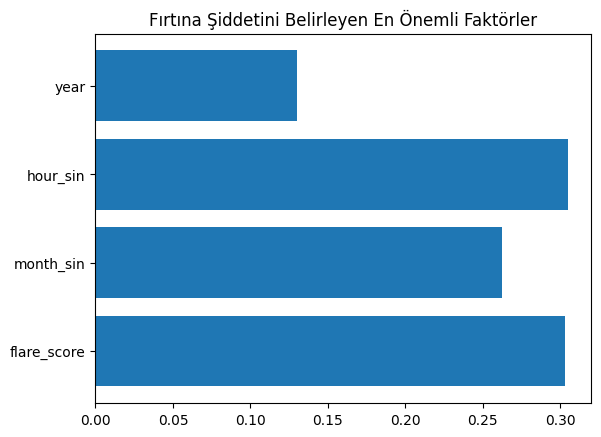

In [12]:
import matplotlib.pyplot as plt

importances = model.feature_importances_
plt.barh(features, importances)
plt.title("Fırtına Şiddetini Belirleyen En Önemli Faktörler")
plt.show()